### Data Cleaning

**Q1. Missing Data Identification**<br>
**Scenario:**
  The hospital suspects incomplete patient records.
  
**Task:**
- Identify missing values in each column
- Calculate percentage of missing data

In [ ]:
import pandas as pd

df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Identify missing values in each column
print(f"Rows to be removed: {df.isnull().any(axis=1).sum()}")

# Calculate percentage of missing data
print(f"Total Data Loss: {(df.isnull().any(axis=1).sum() / len(df)) * 100:.2f}%")

Rows to be removed: 600
Total Data Loss: 11.76%


**Q2. Handling Missing Age**<br>
**Scenario:**
  Age is critical for medical analysis, but some values are missing.

**Task:**
- Replace missing Age values with an appropriate method
- Justify your choice (mean/median)

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

# Justification: Used Median because age may have outliers. 
# The median is robust to these extremes compared to the mean.

**Q3. Handling Missing Treatment Cost**<br>
**Scenario:**
Treatment cost is highly skewed due to expensive treatments.

**Task:**
- Handle missing Treatment_Cost values
- Choose the correct imputation method and explain why

In [9]:
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

# Justification: Use Median. Since the scenario mentions treatment cost is highly skewed,
# the mean would be biased by expensive outliers. The median represents the central 50th percentile.

**Q4. Duplicate Patient Records**<br>
**Scenario:**
Some patient records were entered multiple times.

**Task:**
- Identify duplicate rows
- Remove duplicates
- Compare dataset size before and after

In [10]:
duplicatesCount = df.duplicated().sum()
sizeBefore = df.shape[0]
df = df.drop_duplicates()
sizeAfter = df.shape[0]
print(f"\n{duplicatesCount} duplicates Removed. Size changed from {sizeBefore} to {sizeAfter}.")



99 duplicates Removed. Size changed from 5100 to 5001.


**Q5. Invalid Age Values (Data Quality Check)**<br>
**Scenario:**
Some patients have unrealistic age values (e.g., >100 or <0).

**Task:**
- Detect such records
- Decide whether to remove or correct them

In [11]:
invalidAges = df[(df['Age'] < 0) | (df['Age'] > 100)]
print(f"Number of invalid age records detected: {len(invalidAges)}")

# Action: I will Remove these records as they are likely data entry errors.
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]



Number of invalid age records detected: 0


**Q6. Outlier Detection (Treatment Cost)**<br>
**Scenario:**
Extreme treatment costs are affecting analysis.

**Task:**
- Detect outliers using IQR method
- Display number of outliers

In [12]:
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1
lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5 * IQR

outliers = df[(df['Treatment_Cost'] < lowerBound) | (df['Treatment_Cost'] > upperBound)]
print(f"Total {len(outliers)} Number of outliers in Treatment_Cost")



Total 50 Number of outliers in Treatment_Cost


**Q7. Outlier Treatment**<br>
**Scenario:**
The business team wants to retain all records.

**Task:**
- Apply capping (Winsorization) on Treatment_Cost
- Use 5th and 95th percentile

In [13]:
p5 = df['Treatment_Cost'].quantile(0.05)
p95 = df['Treatment_Cost'].quantile(0.95)
df['Treatment_Cost_Capped'] = df['Treatment_Cost'].clip(lower=p5, upper=p95)

**Q8. Transformation**<br>
**Scenario:**
Treatment cost is highly skewed.

**Task:**
- Apply log transformation
- Create a new column
- Compare before vs after distribution

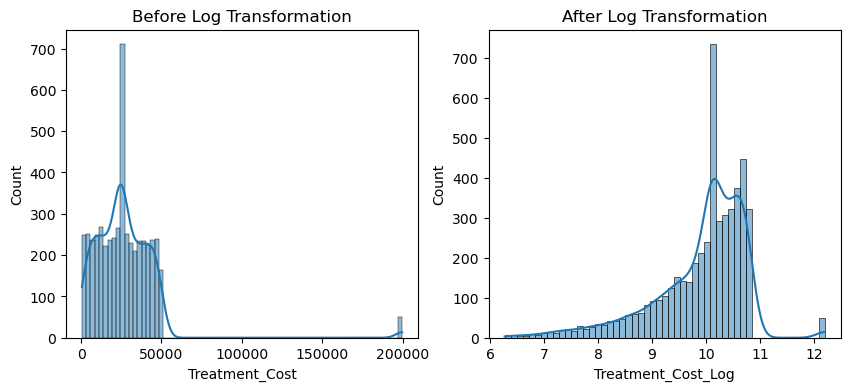

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])

# Visualization (Optional Check)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Treatment_Cost'], kde=True)
plt.title("Before Log Transformation")
plt.subplot(1, 2, 2)
sns.histplot(df['Treatment_Cost_Log'], kde=True)
plt.title("After Log Transformation")
plt.show()



**Q9. Time-Based Missing Handling**<br>
**Scenario:**
Admission dates should follow a logical sequence.

**Task:**
- Sort data by Admission_Date
- Apply forward fill or backward fill where appropriate
- Justify your choice

In [16]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df = df.sort_values(by='Admission_Date')

df['Admission_Date'] = df['Admission_Date'].ffill().bfill()
# Justification: Used ffill (Forward Fill). In medical records, subsequent data entries often
# share temporal context with the preceding entry. bfill is used as a fallback for the first row.